### Step 0 > Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
folder_name_1 = "Image"
folder_name_2 = "Signal"

os.makedirs(folder_name_1, exist_ok=True)
os.makedirs(folder_name_2, exist_ok=True)

### Step 1 > Design a Signal

(4096,) float64
(4096,) float64


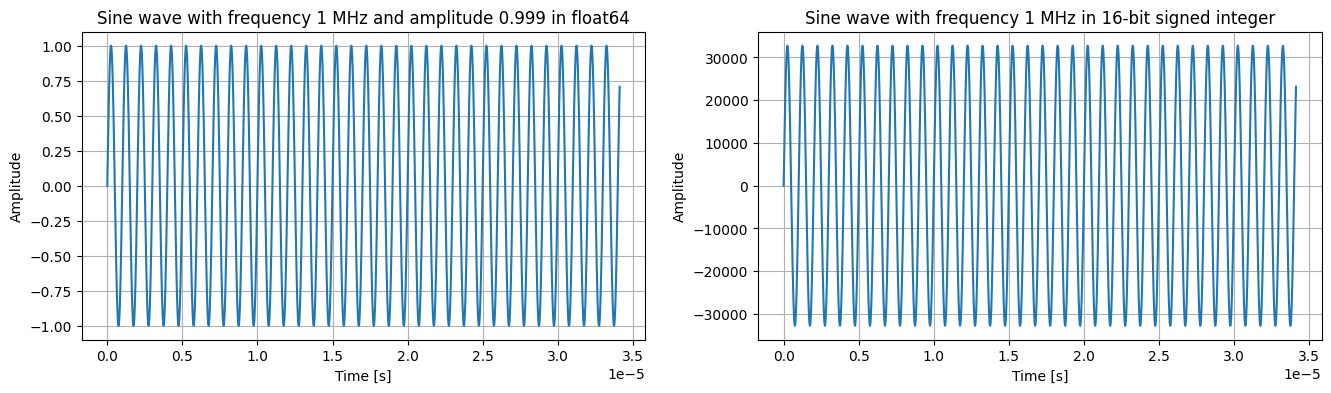

In [3]:
Fs = 120e6
N  = 4096
t  = np.arange(N) / Fs

print(t.shape, t.dtype)

A1 = 0.999
f1 = 1e6
y1 = A1*np.sin(2*np.pi*f1*t) # in float64

y2 = np.round(y1 * (2**15)).astype(np.int16)  # Scale to 16-bit signed integer range 

print(t.shape, t.dtype)

plt.figure(figsize = [16, 4])
plt.subplot(1, 2, 1)
plt.plot(t,y1)
plt.title("Sine wave with frequency 1 MHz and amplitude 0.999 in float64")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t,y2)
plt.title("Sine wave with frequency 1 MHz in 16-bit signed integer")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [4]:
filename = f"{folder_name_2}/input_signal.txt"
with open(filename, "w") as f:
    for val in y2:
        hex_val = f"{val & 0xFFFF:04X}" 
        f.write(f"{hex_val}\n")

### Step 2 > Filter Design

#### Decimation

Successfully saved coefficients to 'Signal/filter_coef.coe'.


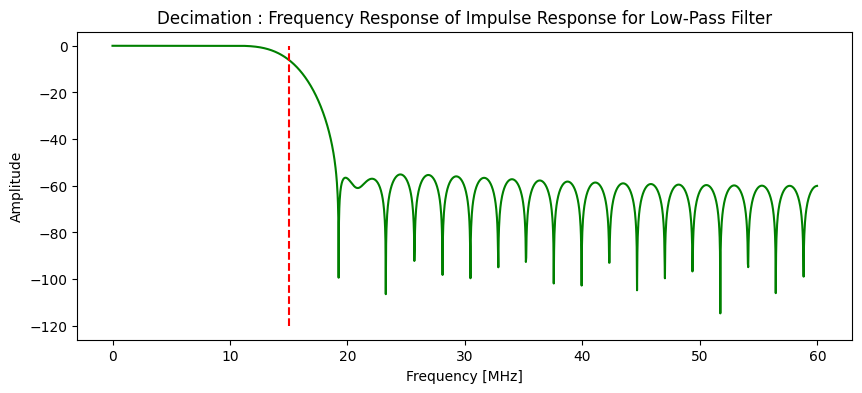

In [5]:
Fs = 120e6
Fc = 15e6 # cutoff frequency

n = 51 # 51-tap low-pass filter
f_norm = Fc/Fs # normalized cutoff frequency in cycles per seconds

h_ideal = 2*f_norm*np.sinc(2*f_norm*(np.arange(n) - (n-1)/2)) # ideal impulse response
#apply windowing to reduce ripples in the frequency response
h_practical = h_ideal * np.hamming(n) # apply Hamming window
h_practical /= np.sum(h_practical) # normalize to ensure unity gain at DC

# this is the frequency response of the filter, which we can use to visualize how well it performs
nfft = 4096
h_practical_freq_domain = np.fft.fft(h_practical, nfft) # zero-padded for better frequency resolution
freq_hz = np.fft.fftfreq(len(h_practical_freq_domain), 1/Fs)
freq_mhz = freq_hz / 1e6

filename = f"{folder_name_2}/filter_coef.coe"
with open(filename, "w") as f:
    f.write("radix=10;\n") 
    f.write("coefdata=\n")
    
    for i, val in enumerate(h_practical): 
        # The :.10f forces Python to write 0.0000000000 instead of e-19
        if i == len(h_practical) - 1:
            f.write(f"{val:.10f};\n") # Last item gets a semicolon
        else:
            f.write(f"{val:.10f},\n") # Others get a comma

print(f"Successfully saved coefficients to '{filename}'.")

plt.figure(figsize = [10, 4])
plt.plot(freq_mhz[:nfft//2],(20*np.log10(np.abs(h_practical_freq_domain)))[:nfft//2], 'green')
plt.vlines(Fc/1e6, -120, 0, color='red', linestyle='--', label='Cutoff Frequency (15 MHz)')
plt.title("Decimation : Frequency Response of Impulse Response for Low-Pass Filter")
plt.xlabel('Frequency [MHz]')
plt.ylabel('Amplitude')
plt.show()

#### Interpolation

Successfully saved coefficients to 'Signal/interpolator_coef.coe'.


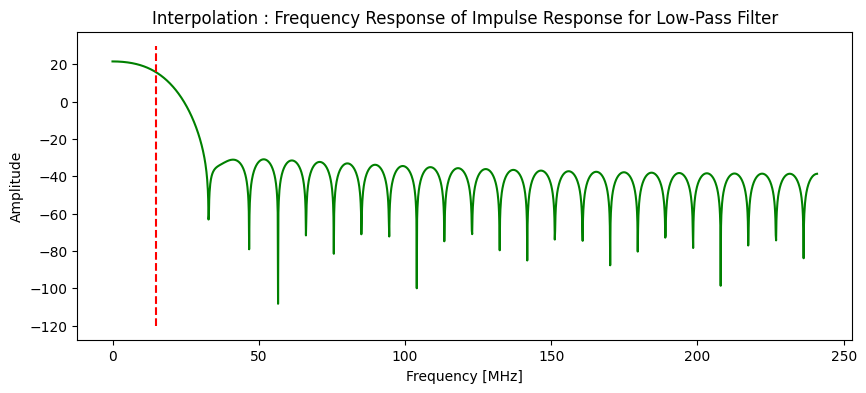

In [6]:
Fs = 482e6
Fc = 15e6 # cutoff frequency

L = 12
n = 51 # 51-tap low-pass filter

f_norm = Fc/Fs # normalized cutoff frequency in cycles per seconds

h_ideal = 2*f_norm*np.sinc(2*f_norm*(np.arange(n) - (n-1)/2)) # ideal impulse response
#apply windowing to reduce ripples in the frequency response
h_practical = h_ideal * np.hamming(n) # apply Hamming window
# h_practical /= np.sum(h_practical) # normalize to ensure unity gain at DC
h_practical = (h_practical / np.sum(h_practical)) * L

# this is the frequency response of the filter, which we can use to visualize how well it performs
nfft = 4096
h_practical_freq_domain = np.fft.fft(h_practical, nfft) # zero-padded for better frequency resolution
freq_hz = np.fft.fftfreq(len(h_practical_freq_domain), 1/Fs)
freq_mhz = freq_hz / 1e6

filename = f"{folder_name_2}/interpolator_coef.coe"
with open(filename, "w") as f:
    f.write("radix=10;\n") 
    f.write("coefdata=\n")
    
    for i, val in enumerate(h_practical): 
        # The :.10f forces Python to write 0.0000000000 instead of e-19
        if i == len(h_practical) - 1:
            f.write(f"{val:.10f};\n") # Last item gets a semicolon
        else:
            f.write(f"{val:.10f},\n") # Others get a comma

print(f"Successfully saved coefficients to '{filename}'.")

plt.figure(figsize = [10, 4])
plt.plot(freq_mhz[:nfft//2],(20*np.log10(np.abs(h_practical_freq_domain)))[:nfft//2], 'green')
plt.vlines(Fc/1e6, -120, 30, color='red', linestyle='--', label='Cutoff Frequency (15 MHz)')
plt.title("Interpolation : Frequency Response of Impulse Response for Low-Pass Filter")
plt.xlabel('Frequency [MHz]')
plt.ylabel('Amplitude')
plt.show()

### Step 3 > Extracting the Signal Data

Saved figure to: /Image/signal_comparison.png


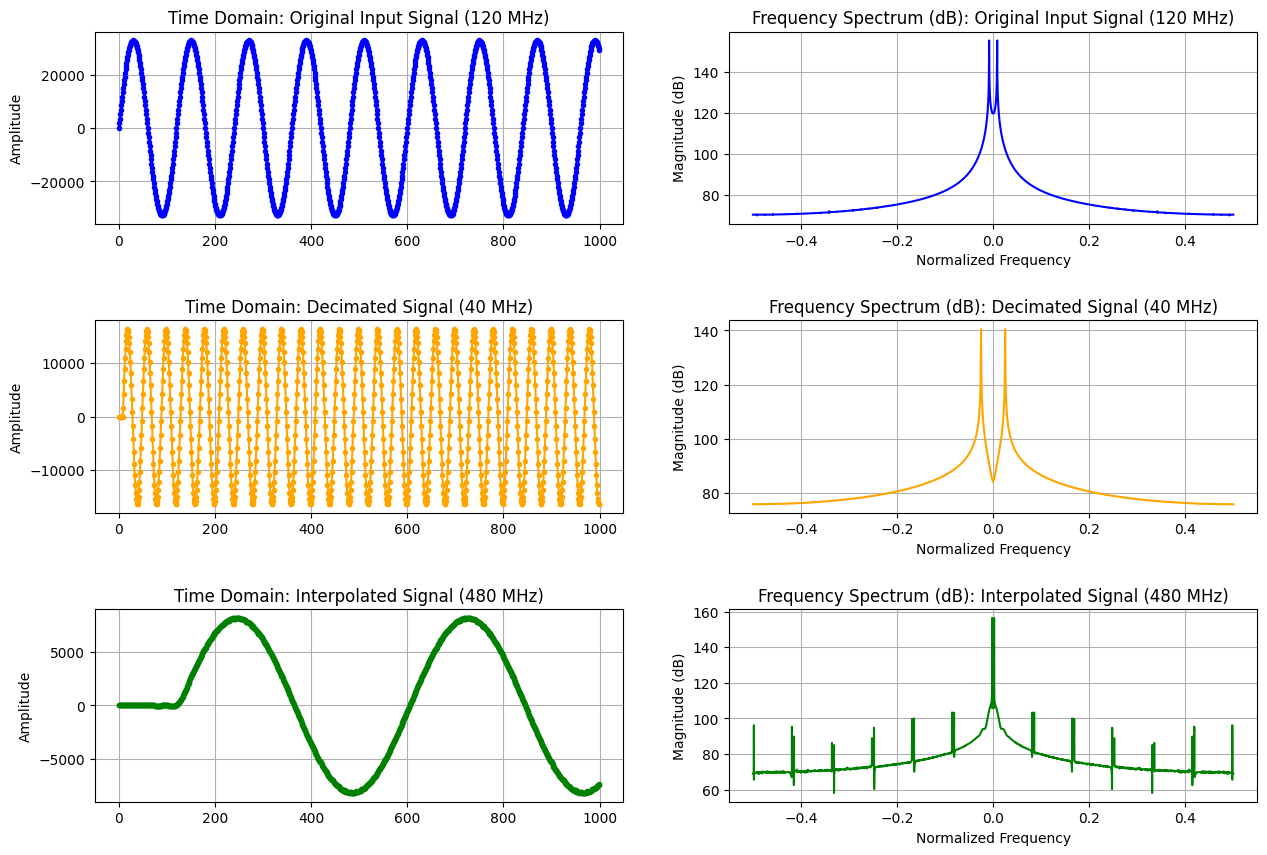

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function to convert 16-bit Hex (Two's Complement) to standard Integers
def read_hex_file(filename):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Convert hex string to integer
            val = int(line, 16)
            # Handle 16-bit signed two's complement
            if val >= 0x8000:
                val -= 0x10000
            data.append(val)
    return np.array(data)

# Read the three files
input_sig = read_hex_file(f'{folder_name_2}/input_signal.txt')
dec_sig = read_hex_file(f'{folder_name_2}/decimated_signal.txt')
interp_sig = read_hex_file(f'{folder_name_2}/interpolated_signal.txt')

# Set up the plots
fig, axs = plt.subplots(3, 2, figsize=(15, 10))
plt.subplots_adjust(hspace=0.5)

signals = [
    (input_sig, "Original Input Signal (120 MHz)", "blue"),
    (dec_sig, "Decimated Signal (40 MHz)", "orange"),
    (interp_sig, "Interpolated Signal (480 MHz)", "green")
]

for i, (sig, title, color) in enumerate(signals):
    # 1. Plot Time Domain (First 200 samples to see the wave clearly)
    axs[i, 0].plot(sig[:1000], marker='o', markersize=3, linestyle='-', color=color)
    axs[i, 0].set_title(f"Time Domain: {title}")
    axs[i, 0].set_ylabel("Amplitude")
    axs[i, 0].grid(True)
    
    # 2. Plot Frequency Domain (FFT)
    # Ignore the first 50 samples to bypass the filter startup latency (transient response)
    stable_sig = sig[50:] 
    fft_mag = np.abs(np.fft.fftshift(np.fft.fft(stable_sig)))
    
    # Convert to dB for better viewing (add tiny number to avoid log(0))
    fft_db = 20 * np.log10(fft_mag + 1e-12)
    
    # Create normalized frequency axis (-0.5 to 0.5)
    freqs = np.linspace(-0.5, 0.5, len(fft_db))
    
    axs[i, 1].plot(freqs, fft_db, color=color)
    axs[i, 1].set_title(f"Frequency Spectrum (dB): {title}")
    axs[i, 1].set_ylabel("Magnitude (dB)")
    axs[i, 1].set_xlabel("Normalized Frequency")
    axs[i, 1].grid(True)

output_filename = f'{folder_name_1}/signal_comparison.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Saved figure to: /{output_filename}")
plt.show()